In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/LungCancer_DataSet.csv")
print("Original coloumn headers:")
print(list(df.columns))

Original coloumn headers:
['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage', 'family_history', 'smoking_status', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type', 'end_treatment_date', 'survived']


## Load the preprocessed data




In [ ]:
df_preprocessed = pd.read_csv("/content/preprocessed_lung_cancer_data.csv")
print(f"Shape of the preprocessed DataFrame: {df_preprocessed.shape}")

Shape of the preprocessed DataFrame: (100211, 41)


## Split the data



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_preprocessed.drop(['survived', 'id', 'diagnosis_date', 'end_treatment_date'], axis=1)
y = df_preprocessed['survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80168, 37)
Shape of X_test: (20043, 37)
Shape of y_train: (80168,)
Shape of y_test: (20043,)


## Handle class imbalance



In [ ]:
print("Distribution of 'survived' in y_train before SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the shape of the resampled training data
print("\nShape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)

# Check the distribution of the target variable after SMOTE
print("\nDistribution of 'survived' in y_train_resampled after SMOTE:")
print(y_train_resampled.value_counts())

Distribution of 'survived' in y_train before SMOTE:
survived
0    62479
1    17689
Name: count, dtype: int64

Shape of X_train_resampled: (124958, 37)
Shape of y_train_resampled: (124958,)

Distribution of 'survived' in y_train_resampled after SMOTE:
survived
0    62479
1    62479
Name: count, dtype: int64


## Hyperparameter tuning




In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Instantiate KNeighborsClassifier
knn_model = KNeighborsClassifier()

# Define the parameter grid
param_grid = {'n_neighbors': [3, 5, 7, 9, 11],
              'weights': ['uniform', 'distance']}

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=knn_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1)

# Fit GridSearchCV to the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Print the best hyperparameters
print("Best hyperparameters found:", grid_search.best_params_)

# Retrieve the best model
best_knn_model = grid_search.best_estimator_

Best hyperparameters found: {'n_neighbors': 3, 'weights': 'distance'}


## Train the k-nn model



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate a KNeighborsClassifier using the best hyperparameters found
best_knn_model = KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors'],
                                      weights=grid_search.best_params_['weights'])

# Train the k-NN model with the best hyperparameters
best_knn_model.fit(X_train_resampled, y_train_resampled)

print("k-NN model with the best hyperparameters trained successfully.")

k-NN model with the best hyperparameters trained successfully.


## Evaluate the model




In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set using the best tuned model
y_pred_tuned = best_knn_model.predict(X_test)

# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

# Print the evaluation metrics for the tuned model
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-score: {f1_tuned:.4f}")

Accuracy: 0.6286
Precision: 0.2186
Recall: 0.2702
F1-score: 0.2417


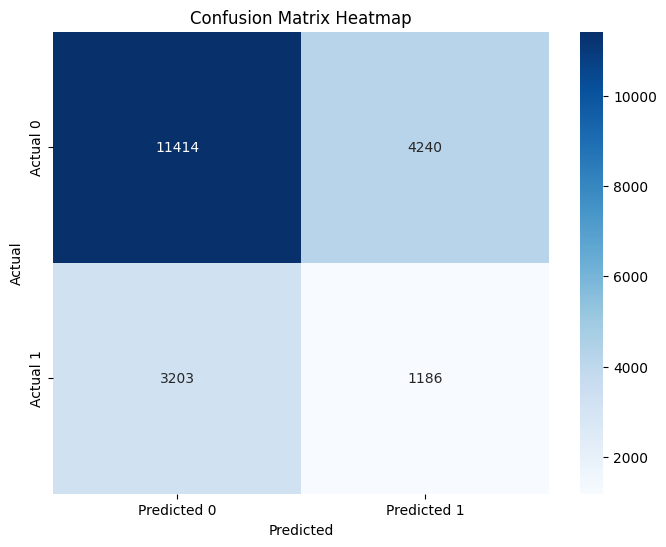

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The preprocessed data, with a shape of (100211, 41), was successfully loaded.
*   The data was split into training (80168 samples) and testing (20043 samples) sets, with 37 features.
*   The training data initially showed a significant class imbalance in the target variable 'survived', with 62479 instances of class 0 and 17689 instances of class 1.
*   Applying SMOTE to the training data successfully balanced the class distribution, resulting in 62479 instances for both class 0 and class 1 in the resampled training set.
*   Hyperparameter tuning using GridSearchCV identified the best hyperparameters for the k-NN model as `n_neighbors=3` and `weights='distance'`.
*   The k-NN model trained with the best hyperparameters achieved the following performance metrics on the test set: Accuracy: 0.6286, Precision: 0.2186, Recall: 0.2702, and F1-score: 0.2417.

### Insights or Next Steps

*   The low Precision and F1-score suggest that the k-NN model, even after balancing the training data and hyperparameter tuning, struggles to correctly identify the positive class ('survived').
*   Consider exploring other classification algorithms, such as Logistic Regression, Support Vector Machines, or tree-based models, which might be more suitable for this dataset and potentially yield better performance metrics, especially for the minority class.
